Load the Data

In [17]:
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import silhouette_score
from scipy.stats import mode
from sklearn.cluster import KMeans

In [3]:
# Load directly from Keras (this fetches from the web or cache)
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


In [4]:
X_train[6]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   1,   0,   3,
          1,   0,   4,   0,   0,   0,   2,   0,   0,   0,   0,   5,   1,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   4,
          0,   0,   0,   0,   0, 106, 229,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,   0,
          0,   0,  90, 138, 223, 214, 209, 167,   0,   0,   0,   6, 124,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   1,   0,   0,   0,  37,
        122, 179, 249, 214, 195, 181, 213, 241,   0,   0,   0,  94, 179,
          0,   0],
       [  0,   0,   0,   2,   0,   6,   0,   0,   0,   0,  16, 149, 236,
        226, 201, 195, 200, 204, 155, 209, 116,   0,  22, 109, 251,  35,
         51,   0],
       [  0,   0,   1,   3,   0,   0,   0,   0,  67, 150, 240, 221, 194,
        190, 204, 214, 205, 195, 207, 185, 206, 233, 224, 179,   2,  10,
         22,   0],
       [  0,   0,   0,   0,   0,   0, 110, 214, 237, 209, 196, 192, 215,
        215, 213, 213, 207, 193, 186, 199, 206, 175,   0,   0, 124, 230,
        200,  36],
       [  0,  50, 119, 158, 166, 192, 204, 198, 187, 202, 203, 211, 214,
        204, 209, 210, 204, 197, 191, 190, 191, 229, 230, 242, 214, 193,
        203, 137],
       [108, 190, 199, 200, 194, 199, 194, 195, 199, 200, 189, 187, 191,
        189, 197, 198, 205, 200, 200, 208, 213, 215, 212, 213, 209, 202,
        216, 137],
       [ 15,  55, 114, 157, 188, 207, 216, 220, 217, 219, 221, 242, 240,
        243, 249, 253, 255, 255, 243, 232, 226, 222, 221, 213, 215, 198,
        209,  62],
       [ 16,  11,   0,   0,   7,  40,  76, 108, 134, 142, 143, 145, 143,
        123, 111,  92,  76,  61,  45,  35,  25,  25,  31,  32,  32,  12,
          1,   0],
       [  0,  11,  25,  26,  26,  22,  12,  20,  15,  15,  18,  17,  19,
         27,  30,  36,  41,  49,  57,  66,  79,  84,  79,  83,  93,  80,
         75,  45],
       [  0,   0,   0,   0,   0,   9,  14,  17,  27,  34,  39,  39,  42,
         44,  41,  41,  43,  48,  43,  30,  31,  35,  40,  37,  40,  37,
         26,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   

Example Data point (image)

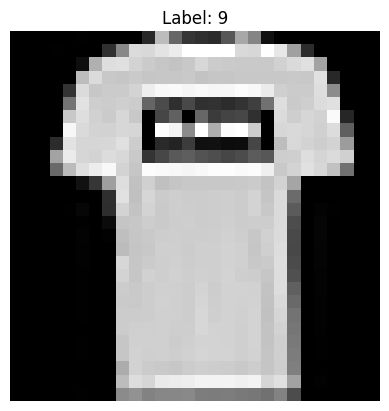

In [5]:
plt.imshow(X_train[1], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.axis('off')
plt.show()

Build Manual K-means Clustering Model (Using imy own functions)

In [6]:
def kmeans_manual(
    X: np.ndarray,
    k: int,
    max_iters: int = 100,
    tol: float = 1e-4,
    n_init: int = 10,
    random_state: int = 42,
):
    """
    Manual K-Means clustering (NumPy only).

    Returns:
      best_centroids: (k, d)
      best_labels:    (n,)
      best_inertia:   float  (WCSS)
    """
    rng_master = np.random.default_rng(random_state)

    n, d = X.shape
    best_inertia = np.inf
    best_centroids = None
    best_labels = None

    for init in range(n_init):
        # --- init centroids by sampling k points
        rng = np.random.default_rng(rng_master.integers(0, 1_000_000_000))
        centroids = X[rng.choice(n, size=k, replace=False)].copy()

        prev_inertia = np.inf

        for it in range(max_iters):
            # --- Assignment step: compute squared distances to each centroid (WCSS)
            # distances shape: (n, k)
            distances = ((X[:, None, :] - centroids[None, :, :]) ** 2).sum(axis=2)

            # nearest centroid for each point
            labels = distances.argmin(axis=1)

            # inertia (WCSS): sum of squared distances to assigned centroids
            inertia = distances[np.arange(n), labels].sum()

            # --- Update step: recompute centroids as mean of assigned points
            new_centroids = np.zeros((k, d), dtype=X.dtype)
            for ci in range(k):
                mask = labels == ci
                if np.any(mask):
                    new_centroids[ci] = X[mask].mean(axis=0)
                else:
                    # Empty cluster: re-seed centroid to a random point
                    new_centroids[ci] = X[rng.integers(0, n)]

            # --- Convergence checks
            centroid_shift = np.linalg.norm(new_centroids - centroids)
            improvement = prev_inertia - inertia

            centroids = new_centroids
            prev_inertia = inertia

            if centroid_shift < tol or improvement >= 0 and improvement < tol:
                break

        # keep the best run across n_init
        if inertia < best_inertia:
            best_inertia = inertia
            best_centroids = centroids
            best_labels = labels

    return best_centroids, best_labels, best_inertia


In [7]:
# Load data (labels are NOT used for training; only for evaluation)
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
X = np.concatenate([X_train, X_test], axis=0)
y = np.concatenate([y_train, y_test], axis=0)

# Flatten + scale
X = X.reshape(len(X), -1).astype(np.float32) / 255.0

# Optional: subsample for speed
rng = np.random.default_rng(42)
idx = rng.choice(len(X), size=20000, replace=False)
X_sub = X[idx]
y_sub = y[idx]

# PCA to make clustering faster + cleaner
pca = PCA(n_components=50, random_state=42)
X_sub_pca = pca.fit_transform(X_sub)

# Manual K-Means
centroids, cluster_labels, inertia = kmeans_manual(
    X_sub_pca, k=10, max_iters=100, tol=1e-4, n_init=5, random_state=42
)

print("Done. Inertia:", inertia)
print("Cluster labels:", np.unique(cluster_labels))


Done. Inertia: 449859.88
Cluster labels: [0 1 2 3 4 5 6 7 8 9]


Build Python K-means Clustering Model (Using in-built functions)

In [8]:
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

kmeans = KMeans(n_clusters=10, n_init=20, random_state=42)
y_kmeans = kmeans.fit_predict(X_train_flat)

# Step 4: Normalize pixel values (0–255 → 0–1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train_flat)

In [9]:
# Step 5: Train K-Means model
n_samples = 30000
X_sample = X_train_flat[:n_samples]
y_sample = y_train[:n_samples]


# Step 5: Train K-Means model
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
kmeans.fit(X_sample)

KMeans(n_clusters=10, n_init=10, random_state=42)

Evaluating Manual Model

In [10]:
sil = silhouette_score(X_sub_pca, cluster_labels)
print("Silhouette score:", sil)


k = 10  # number of clusters

confusion = np.zeros((k, k), dtype=int)
for c, t in zip(cluster_labels, y_sub):
    confusion[c, t] += 1

row_ind, col_ind = linear_sum_assignment(-confusion)
accuracy = confusion[row_ind, col_ind].sum() / confusion.sum()

print(f"Cluster accuracy (Hungarian-matched): {accuracy:.2%}")


Silhouette score: 0.19750461
Cluster accuracy (Hungarian-matched): 55.06%


Evaluating Python Model

In [11]:
# Step 6: Get cluster labels
y_pred = kmeans.labels_

In [12]:
def map_clusters_to_labels(y_true, y_pred):
    labels = np.zeros_like(y_pred)
    for i in range(10):
        mask = (y_pred == i)
        labels[mask] = mode(y_true[mask], keepdims=True)[0]
    return labels

y_mapped = map_clusters_to_labels(y_sample, y_pred)

# Step 8: Compute accuracy
acc = accuracy_score(y_sample, y_mapped)
print(f"Cluster accuracy: {acc * 100:.2f}%")

Cluster accuracy: 55.25%


Cluster 2 has no samples.
Cluster 3 has no samples.


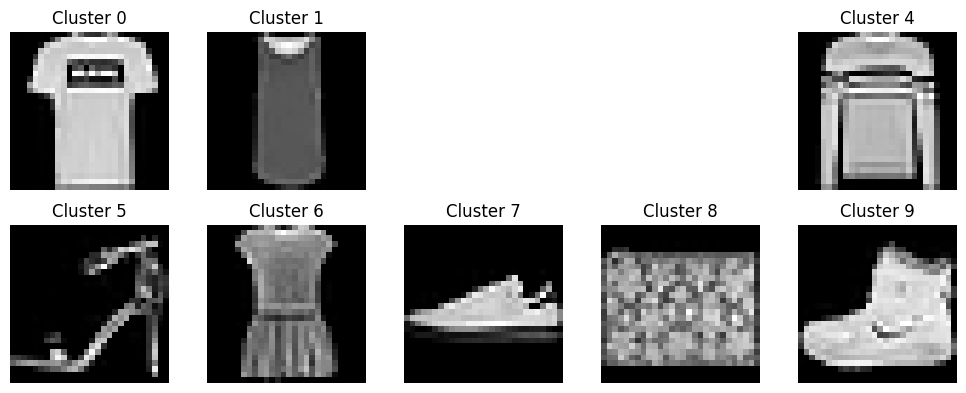

In [13]:
# Step 9: Visualize sample results
labels_map = {
    0: "T-shirt/top", 1: "Trouser", 2: "Pullover", 3: "Dress",
    4: "Coat", 5: "Sandal", 6: "Shirt", 7: "Sneaker", 8: "Bag", 9: "Ankle boot"
}

plt.figure(figsize=(10, 4))

for i in range(10):
    idx = np.where(y_mapped == i)[0]
    if len(idx) == 0:  # skip if no samples in this cluster
        print(f"Cluster {i} has no samples.")
        continue
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[idx[0]].reshape(28, 28), cmap='gray')
    plt.title(f"Cluster {i}")
    plt.axis('off')

plt.tight_layout()
plt.show()

##**Graphs**

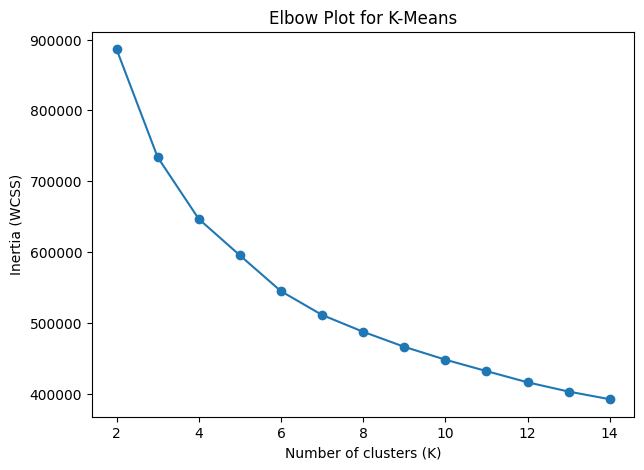

In [14]:
# X_sub_pca should be your feature matrix (e.g., PCA-reduced Fashion-MNIST)
# Example: X_sub_pca = pca.fit_transform(X_sub)

Ks = range(2, 15)
inertias = []

for k in Ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_sub_pca)
    inertias.append(km.inertia_)  # WCSS / inertia

plt.figure(figsize=(7, 5))
plt.plot(Ks, inertias, marker='o')
plt.title("Elbow Plot for K-Means")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia (WCSS)")
plt.show()

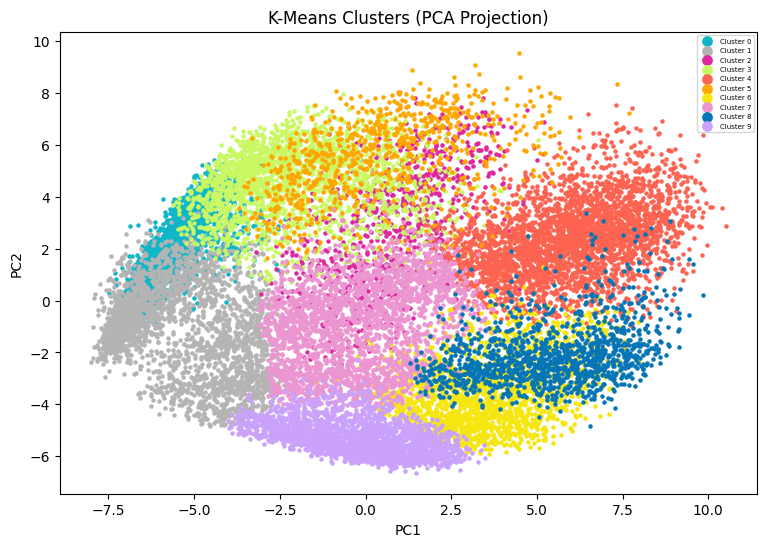

In [24]:
from matplotlib.colors import ListedColormap
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_sub_pca)
colors = [

    #orange
    #red
    #pink
    #purple
    #blue
    #cyan
    #green
    #dark green
    #grey

    "#0EB6C7",  # cyan 1
    "#B5B3B3",  # gray 9
    "#DE269E",  # pink 5
    "#C9F863",  # green 3
    "#FC6351",  # red 10
    "#FFA700",  # orange 4
    "#F5E60F",  #yellow 8
    "#EB96D1",  # light pink 6
    "#0575B5", # blue 5
    "#CAA2FC",  # purple 7
]

# Scatter plot colored by cluster assignment
plt.figure(figsize=(9, 6))

for k in range(len(colors)):
    mask = cluster_labels == k
    plt.scatter(
        X_2d[mask, 0],
        X_2d[mask, 1],
        s=5,
        color=colors[k],
        label=f"Cluster {k}"
    )

plt.title("K-Means Clusters (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(markerscale=3, fontsize=5)
plt.show()

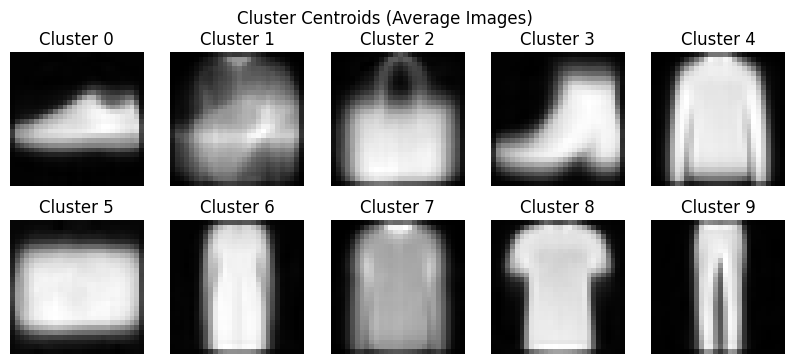

In [16]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    centroid_img = pca.inverse_transform(centroids[i]).reshape(28, 28)
    ax.imshow(centroid_img, cmap='gray')
    ax.set_title(f"Cluster {i}")
    ax.axis('off')

plt.suptitle("Cluster Centroids (Average Images)")
plt.show()